In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/bmo_internet_monitoring/monitoring_logs.csv')

In [ ]:
print(df.shape)
print(df.head())

(1000, 7)
      id                waktu isp_name                            status  \
0  10857  2026-05-22 20:52:50  Linknet  Tidak Ada Gangguan pada Jaringan   
1  10858  2026-05-22 20:55:53  Linknet                         SPEEDTEST   
2  10859  2026-05-22 21:05:33  Linknet                         SPEEDTEST   
3  10860  2026-05-22 21:09:31  Linknet        Router Internal Bermasalah   
4  10861  2026-05-22 21:09:36  Linknet  Tidak Ada Gangguan pada Jaringan   

   ping_ms  download_mbps  upload_mbps  
0    15.55           0.00         0.00  
1    21.13          90.72       107.51  
2    18.53          90.51       107.11  
3     0.00           0.00         0.00  
4    15.70           0.00         0.00  


**TOTAL — dari sekian gangguan, jenisnya apa aja dan proporsinya berapa?**

In [ ]:
# Jam berapa gangguan paling sering terjadi?
# Kalau ada pertanyaan seperti itu, berarti HARUS extract informasi mengenai waktu
# kenapa gak tinggal baca aja informasi yg terpampang di df.shape atau df.head cell sebelumnya?
# karena python masih menganggap informasi mengenai waktu (tgl & jam) merupakan informasi teks biasa seperti tulisan lainnya
# untuk bisa memanipulasinya, kita butuh ekstrak dengan cara berikut:

df['waktu'] = pd.to_datetime(df['waktu'])
df['jam'] = df['waktu'].dt.hour

print(df[['waktu', 'jam']].head(10))

# [NOTE] df['waktu'] & df['jam'] yg menjadi variabel di atas artinya python sedang membuka lemari dataframe yg di dalamnya terdapat laci (nama kolom) waktu dan jam
# nama laci/ kolomnya ketauan kan pas awal buka file dengan ngeprint info & shape

                waktu  jam
0 2026-05-22 20:52:50   20
1 2026-05-22 20:55:53   20
2 2026-05-22 21:05:33   21
3 2026-05-22 21:09:31   21
4 2026-05-22 21:09:36   21
5 2026-05-22 21:10:34   21
6 2026-05-22 21:15:37   21
7 2026-05-22 21:20:39   21
8 2026-05-22 21:25:49   21
9 2026-05-22 21:30:43   21


In [ ]:
#setelah extract waktu, fokus ke informasi yg negatif
#artinya, baris dengan status 'SPEEDTEST' dan 'TIDAK ADA GANGGUAN PADA JARINGAN' harus diabaikan dan fokus ke analisis yang bermasalah

gangguan = df[df['status'] != 'SPEEDTEST']
gangguan = gangguan[gangguan['status'] != 'Tidak Ada Gangguan pada Jaringan']

print(gangguan['status'].value_counts())
print('Total Baris Gangguan:', len(gangguan))

status
Akses Internet ke Luar Terganggu    71
Router Internal Bermasalah          52
Gangguan ISP Gedung                 19
Name: count, dtype: int64
Total Baris Gangguan: 142


In [ ]:
#menghitung gangguan per jamnya

per_jam = gangguan.groupby('jam')['status'].count()
print(per_jam)

jam
0      3
1      7
2      6
3     10
4      5
5      6
6     11
7     19
8     13
9      4
10     4
11    11
12     9
13     7
14     1
15     4
16     2
17     7
19     3
20     1
21     4
22     2
23     3
Name: status, dtype: int64


In [ ]:
per_jam.max()

19

In [ ]:
#liat, gangguan terbanyak di jam 7 pagi kan, kok bisa?
#untuk memastikan, cek dulu emg di jam 7 ada brp total data yg masuk?

#perbandingan-> total data per jam vs gangguan per jamnya
#ini adalah langkah normalisasi agar bisa dibandingkan antar jam dgn cara dibagi total data dulu

total_per_jam = df.groupby('jam')['status'].count()
gangguan_per_jam = gangguan.groupby('jam')['status'].count()

perbandingan = pd.DataFrame({
    'total': total_per_jam,
    'gangguan': gangguan_per_jam
}).fillna(0)

perbandingan['persen_gangguan'] = (perbandingan['gangguan'] / perbandingan['total'] *100).round(1)

print(perbandingan)

     total  gangguan  persen_gangguan
jam                                  
0       39       3.0              7.7
1       45       7.0             15.6
2       45       6.0             13.3
3       53      10.0             18.9
4       43       5.0             11.6
5       45       6.0             13.3
6       56      11.0             19.6
7       71      19.0             26.8
8       59      13.0             22.0
9       41       4.0              9.8
10      41       4.0              9.8
11      54      11.0             20.4
12      51       9.0             17.6
13      47       7.0             14.9
14      25       1.0              4.0
15      30       4.0             13.3
16      26       2.0              7.7
17      36       7.0             19.4
18      22       0.0              0.0
19      28       3.0             10.7
20      26       1.0              3.8
21      41       4.0              9.8
22      37       2.0              5.4
23      39       3.0              7.7


In [ ]:
perbandingan.max()

,0
total,71.0
gangguan,19.0
persen_gangguan,26.8


In [ ]:
total_per_jenis = gangguan['status'].value_counts()
persen = (total_per_jenis / total_per_jenis.sum() * 100).round(1)

ringkasan = pd.DataFrame({
    'jumlah': total_per_jenis,
    'persen': persen
})

print(ringkasan)

                                  jumlah  persen
status                                          
Akses Internet ke Luar Terganggu      71    50.0
Router Internal Bermasalah            52    36.6
Gangguan ISP Gedung                   19    13.4


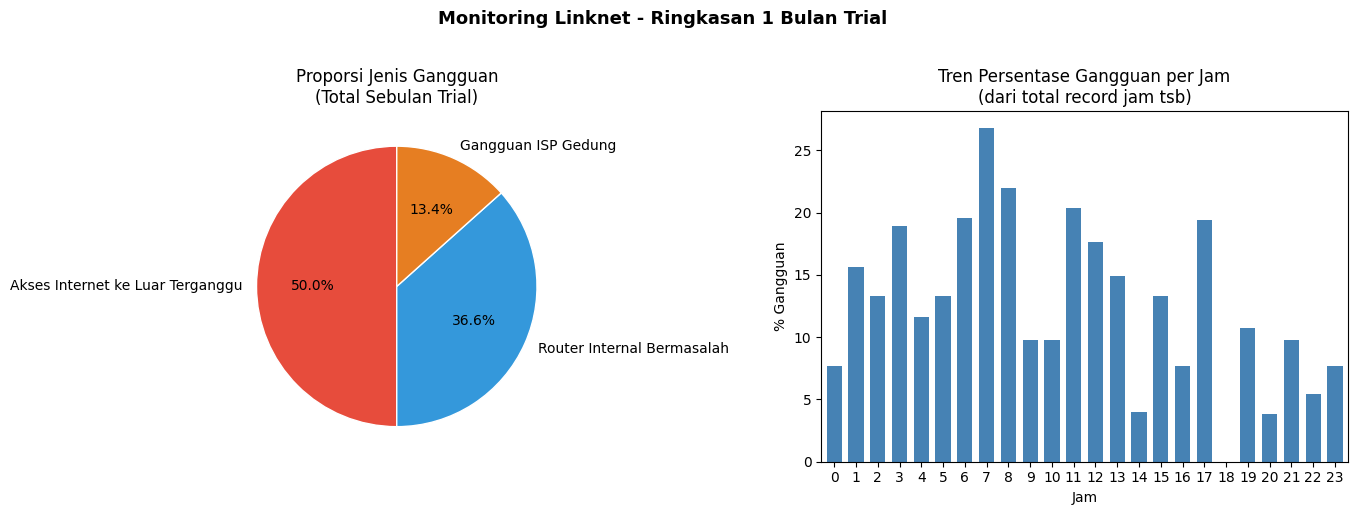

In [ ]:
#visualisasi statistik

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#chart 1: proporsi total
colors = ['#e74c3c', '#3498db', '#e67e22']
axes[0].pie(
    ringkasan['jumlah'],
    labels=ringkasan.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
axes[0].set_title('Proporsi Jenis Gangguan\n(Total Sebulan Trial)')

#chart 2: persentase gangguan per jam
perbandingan['persen_gangguan'].plot(
    kind='bar',
    ax=axes[1],
    color='steelblue',
    width=0.7
)
axes[1].set_xlabel('Jam')
axes[1].set_ylabel('% Gangguan')
axes[1].set_title('Tren Persentase Gangguan per Jam\n(dari total record jam tsb)')
axes[1].set_xticklabels(range(24), rotation=0)

plt.suptitle('Monitoring Linknet - Ringkasan 1 Bulan Trial',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

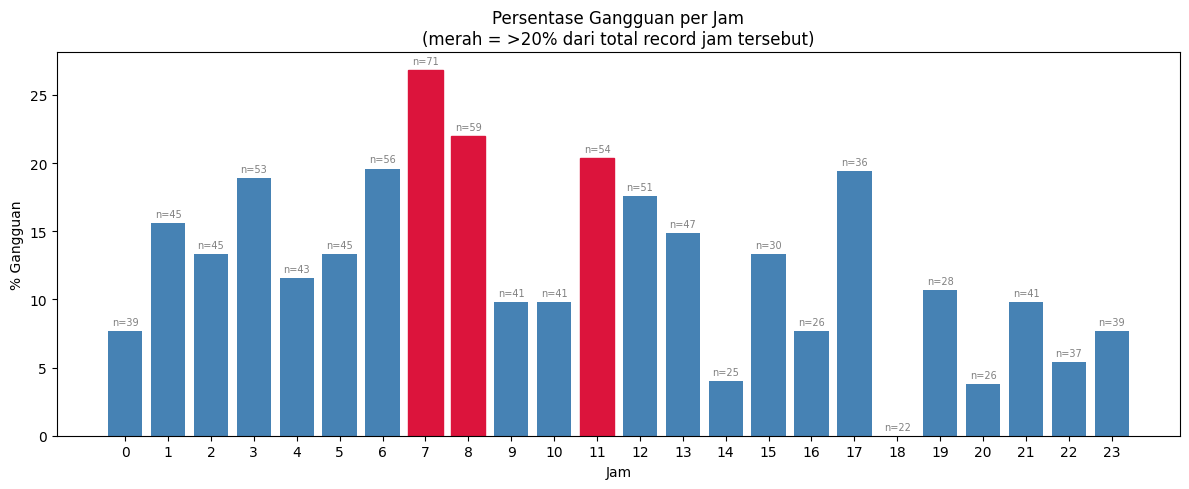

In [ ]:
#visualisasiin datanya
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(perbandingan.index, perbandingan['persen_gangguan'], color='steelblue')

#warna merah = jam paling rawan
for bar, pct in zip(bars, perbandingan['persen_gangguan']):
  if pct > 20:
    bar.set_color('crimson')

#label n= di tiap bar spy sample size keliatan
for bar, total in zip(bars, perbandingan['total']):
  ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
          f'n={int(total)}', ha='center', va='bottom', fontsize=7, color='gray')

ax.set_xlabel('Jam')
ax.set_ylabel('% Gangguan')
ax.set_title('Persentase Gangguan per Jam\n(merah = >20% dari total record jam tersebut)')
ax.set_xticks(range(24))

plt.tight_layout()
plt.show()

#Kesimpulan:
Jam 07.00–08.00 adalah periode paling rawan gangguan jaringan (26.8% dan 22.0%), bertepatan dengan jam masuk kantor dan lonjakan koneksi serentak. Jam 18.00 menunjukkan 0% gangguan namun data terlalu sedikit (n=22) untuk dijadikan kesimpulan.

In [ ]:
#di sini breakdown jenis gangguan seperti apa saja sih di dalamnya
#apakah "Akses Internet ke Luar Terganggu", "Gangguan ISP Gedung", atau "Router Internal Bermasalah"?

breakdown = gangguan.groupby(['jam', 'status']).size().unstack(fill_value=0)
print(breakdown)

status  Akses Internet ke Luar Terganggu  Gangguan ISP Gedung  \
jam                                                             
0                                      2                    0   
1                                      0                    2   
2                                      3                    1   
3                                      4                    3   
4                                      0                    1   
5                                      1                    1   
6                                      8                    3   
7                                     14                    3   
8                                      9                    0   
9                                      2                    0   
10                                     3                    1   
11                                     6                    1   
12                                     6                    1   
13                       

In [ ]:
#di sini breakdown jenis gangguan yg mana dan seberapa banyak terjadi
#apakah "Akses Internet ke Luar Terganggu", "Gangguan ISP Gedung" atau "Router Internal Bermasalah"

breakdown = gangguan.groupby(['jam', 'status']).size().unstack(fill_value=0)
print(breakdown)

status  Akses Internet ke Luar Terganggu  Gangguan ISP Gedung  \
jam                                                             
0                                      2                    0   
1                                      0                    2   
2                                      3                    1   
3                                      4                    3   
4                                      0                    1   
5                                      1                    1   
6                                      8                    3   
7                                     14                    3   
8                                      9                    0   
9                                      2                    0   
10                                     3                    1   
11                                     6                    1   
12                                     6                    1   
13                       

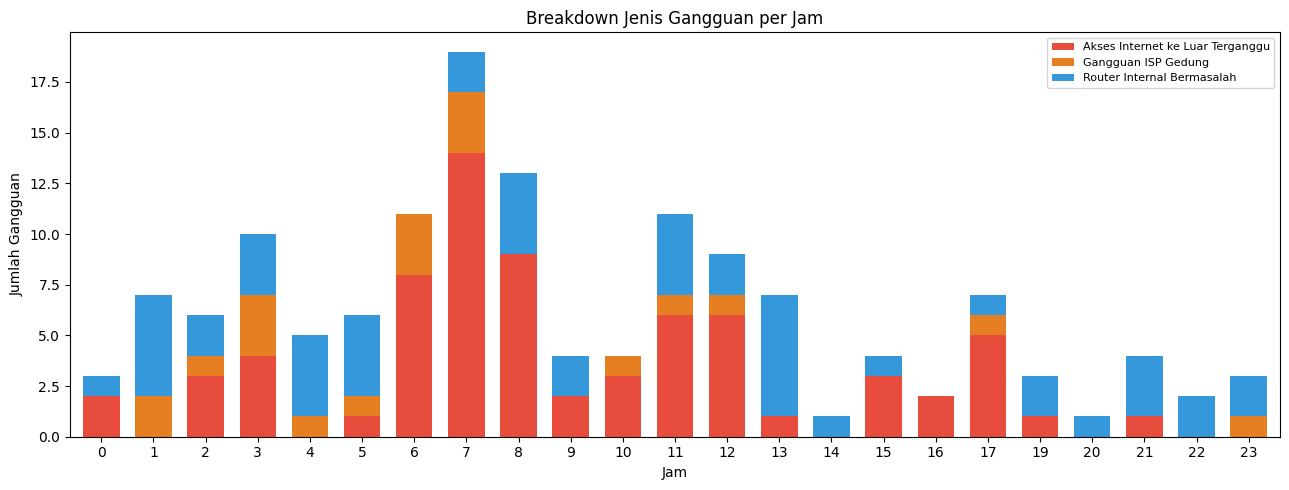

In [ ]:
#visualisasikan hasilnya

fig, ax = plt.subplots(figsize=(13, 5))

breakdown.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#e74c3c', '#e67e22', '#3498db'], #merah, orange, blue (sesuai urutan)
    width=0.7
)

ax.set_xlabel('Jam')
ax.set_ylabel('Jumlah Gangguan')
ax.set_title('Breakdown Jenis Gangguan per Jam')
ax.legend(loc='upper right', fontsize=8)
ax.set_xticklabels(breakdown.index, rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
#filtering noise, apakah gangguan valid atau disebabkan dari bias alatnya sendiri?

#sortir berdasarkan waktu
gangguan = gangguan.sort_values('waktu').reset_index(drop=True)

#tandain setiap pergantian eps
#kalo status baris skrg beda sama baris sebelumnya = eps baru
gangguan['episode'] = (
    gangguan['status'] != gangguan['status'].shift()
).cumsum()

print(gangguan[['waktu', 'status', 'episode']].head(20))

                 waktu                            status  episode
0  2026-05-22 21:09:31        Router Internal Bermasalah        1
1  2026-05-23 00:24:33  Akses Internet ke Luar Terganggu        2
2  2026-05-23 00:24:57  Akses Internet ke Luar Terganggu        2
3  2026-05-23 01:04:59        Router Internal Bermasalah        3
4  2026-05-23 01:10:22        Router Internal Bermasalah        3
5  2026-05-23 01:49:02        Router Internal Bermasalah        3
6  2026-05-23 04:53:21        Router Internal Bermasalah        3
7  2026-05-23 05:20:04        Router Internal Bermasalah        3
8  2026-05-23 05:24:37               Gangguan ISP Gedung        4
9  2026-05-23 05:25:01  Akses Internet ke Luar Terganggu        5
10 2026-05-23 08:06:36        Router Internal Bermasalah        6
11 2026-05-23 08:53:07  Akses Internet ke Luar Terganggu        7
12 2026-05-23 09:42:52        Router Internal Bermasalah        8
13 2026-05-23 10:30:32               Gangguan ISP Gedung        9
14 2026-05

[PERHATIAN!] Di result atas, terutama eps 3, terlihat status 'Router Internal Bermasalah' dari jam 1 s/d jam 5 (>4jam). Jangan dulu percaya, karena ini bug logic. Kenapa bisa? karena artinya sistem anggep router bermasalah padahal kemungkinan besar kejadian tsb kejadian terpisah yg kebetulan statusnya sama.
Hal ini karena pas awal analisis kan sempet difilter si semua baris berstatus Normal dan Speedtest dikecualikan. Ini menyebabkan baris yg di tengah hilang jd keliatan nyambung.

In [ ]:
#buat threshold baru. Eps dianggap beda kalau gap waktunya lbh dari threshold tertentu, meskipun statusnya sama

#hitung gap waktu antar baris
gangguan['gap_menit'] = gangguan['waktu'].diff().dt.total_seconds() / 60

#eps baru kalo status beda OR gap >30 mnt
#kenapa decide 30mnt instead of 60mnt?
#sebetulnya bebas, ini keputusan operasional, bukan itung2an matematis
#milih per 30mnt biar refer ke interval speedtest yg jalan per 5mnt
#jd kalo ada gap >30mnt antara 2 baris gangguan yg statusnya sama, kemungkinan besar 2 kejadian berbeda, bkn 1 eps nyambung
gangguan['episode_v2'] = (
    (gangguan['status'] != gangguan['status'].shift()) |
    (gangguan['gap_menit'] > 30)
).cumsum()

print(gangguan[['waktu', 'status', 'gap_menit', 'episode_v2']].head(20))

#30mnt = 6x interval speedtest. Kalau dlm 6x pengukuran gk ada record gangguan,
#wajar dianggap udah pulih dan masuk eps baru.
#Bisa jg ganti dari 30mnt jd 15mnt, or 60mnt, tergantung seberapa sensitif sistemnya.

                 waktu                            status   gap_menit  \
0  2026-05-22 21:09:31        Router Internal Bermasalah         NaN   
1  2026-05-23 00:24:33  Akses Internet ke Luar Terganggu  195.033333   
2  2026-05-23 00:24:57  Akses Internet ke Luar Terganggu    0.400000   
3  2026-05-23 01:04:59        Router Internal Bermasalah   40.033333   
4  2026-05-23 01:10:22        Router Internal Bermasalah    5.383333   
5  2026-05-23 01:49:02        Router Internal Bermasalah   38.666667   
6  2026-05-23 04:53:21        Router Internal Bermasalah  184.316667   
7  2026-05-23 05:20:04        Router Internal Bermasalah   26.716667   
8  2026-05-23 05:24:37               Gangguan ISP Gedung    4.550000   
9  2026-05-23 05:25:01  Akses Internet ke Luar Terganggu    0.400000   
10 2026-05-23 08:06:36        Router Internal Bermasalah  161.583333   
11 2026-05-23 08:53:07  Akses Internet ke Luar Terganggu   46.516667   
12 2026-05-23 09:42:52        Router Internal Bermasalah   49.75

In [ ]:
#filtering terakhir, durasi per eps
#tujuan biar bisa filter mana genuine mana noise

#itung durasi tiap eps
durasi_episode = gangguan.groupby(['episode_v2', 'status']).agg(
    mulai=('waktu', 'min'),
    selesai=('waktu', 'max'),
    jumlah_record=('waktu', 'count')
).reset_index()

durasi_episode['durasi_menit'] = (
    (durasi_episode['selesai'] - durasi_episode['mulai'])
    .dt.total_seconds() / 60
)

print(durasi_episode.sort_values('durasi_menit', ascending=False).head(15))

    episode_v2                            status               mulai  \
81          82  Akses Internet ke Luar Terganggu 2026-05-25 08:04:22   
20          21  Akses Internet ke Luar Terganggu 2026-05-23 16:32:25   
4            5        Router Internal Bermasalah 2026-05-23 04:53:21   
87          88  Akses Internet ke Luar Terganggu 2026-05-25 12:00:43   
15          16        Router Internal Bermasalah 2026-05-23 13:05:56   
75          76        Router Internal Bermasalah 2026-05-25 05:15:15   
56          57        Router Internal Bermasalah 2026-05-24 12:53:41   
62          63        Router Internal Bermasalah 2026-05-24 21:58:12   
48          49  Akses Internet ke Luar Terganggu 2026-05-24 07:14:43   
51          52  Akses Internet ke Luar Terganggu 2026-05-24 07:49:49   
58          59  Akses Internet ke Luar Terganggu 2026-05-24 15:07:03   
52          53        Router Internal Bermasalah 2026-05-24 08:37:18   
55          56        Router Internal Bermasalah 2026-05-24 11:3

In [ ]:
#klasifikasi eps
durasi_episode['kategori'] = durasi_episode['durasi_menit'].apply(
    lambda x: 'noise' if x == 0 else ('perlu_monitor' if x < 5 else 'genuine')
)

summary_kategori = durasi_episode.groupby(['status', 'kategori']).size().unstack(fill_value=0)
print(summary_kategori)
print()
print("Total episode:", len(durasi_episode))
print("Genuine (<5 mnt):", (durasi_episode['kategori'] == 'genuine').sum())
print("Perlu Monitor (1-5 mnt):", (durasi_episode['kategori'] == 'perlu_monitor').sum())
print("Noise (0 mnt):", (durasi_episode['kategori'] == 'noise').sum())

kategori                          genuine  noise  perlu_monitor
status                                                         
Akses Internet ke Luar Terganggu        9     10             10
Gangguan ISP Gedung                     0     17              1
Router Internal Bermasalah              9     33              0

Total episode: 89
Genuine (<5 mnt): 18
Perlu Monitor (1-5 mnt): 11
Noise (0 mnt): 60


KESIMPULAN MONITORING LINKNET — 1 BULAN TRIAL
==============================================

TOTAL GANGGUAN TERCATAT : 142 kejadian (dari 1000 records)
TOTAL EPISODE           : 89 episode unik

PROPORSI JENIS GANGGUAN:
- Akses Internet ke Luar Terganggu : 50.0% (71 kejadian)
- Router Internal Bermasalah       : 36.6% (52 kejadian)  
- Gangguan ISP Gedung              : 13.4% (19 kejadian)

KLASIFIKASI EPISODE:
- Genuine  (>5 menit)  : 18 episode — perlu perhatian
- Perlu Monitor (1-5m) : 11 episode — observasi lanjut
- Noise    (0 menit)   : 60 episode — kemungkinan false positive

JAM PALING RAWAN:
- Jam 07.00 : 26.8% dari total record jam tersebut gangguan
- Jam 08.00 : 22.0%
- Jam 11.00 : 20.4%
→ Berkorelasi dengan jam masuk kantor & lonjakan koneksi serentak

CATATAN PENTING:
1. 50% "Akses ke Luar" perlu divalidasi — kemungkinan noise
   dari speedtest-cli dan single DNS target (belum ada redundancy)
2. Seluruh episode Gangguan ISP berlangsung < 5 menit —
   bisa micro-outage genuine atau false positive,
   perlu cross-check log Linknet untuk konfirmasi
3. Analisis ini perlu digabungkan dengan backend.csv
   untuk gambaran downtime dan temperatur yang lebih lengkap

REKOMENDASI:
- Tambah redundancy DNS (Cloudflare 1.1.1.1 sebagai backup)
- Set alert otomatis jika episode genuine terdeteksi > 5 menit
- Jadwalkan pengecekan fisik router di jam 07.00–08.00



---



In [ ]:
#buka file banckend.csv

with open('/content/drive/My Drive/bmo_internet_monitoring/backend.csv', 'r') as f:
  lines = [f.readline() for _ in range(20)]

for i, line in enumerate(lines):
  print(i, repr(line.strip()))

0 '--- MEMULAI DIAGNOSTIC MONITOR ---'
1 '[DB] Database siap digunakan.'
2 'Target: Linknet'
3 ''
4 '[INFO] Menjalankan Speedtest...'
5 '--- Speedtest: Mencari Server ---'
6 '---Speedtest: Sedang Download ---'
7 '---Speedtest: Sedang Upload ---'
8 'Hasil: DL: 88.27 ; UL: 105.2'
9 '[DB] 1 Data Log Event tersimpan permanen.'
10 ''
11 '[2026-04-24 13:18:43] INTERNET NORMAL ; Tidak Ada Gangguan pada Jaringan (16.03ms) ; Temp: 47.2C'
12 '[2026-04-24 13:18:48] INTERNET NORMAL ; Tidak Ada Gangguan pada Jaringan (15.6ms) ; Temp: 45.8C'
13 '[2026-04-24 13:18:53] INTERNET NORMAL ; Tidak Ada Gangguan pada Jaringan (15.94ms) ; Temp: 45.8C'
14 '[2026-04-24 13:18:58] INTERNET NORMAL ; Tidak Ada Gangguan pada Jaringan (15.37ms) ; Temp: 45.3C'
15 '[2026-04-24 13:19:03] INTERNET NORMAL ; Tidak Ada Gangguan pada Jaringan (16.51ms) ; Temp: 45.8C'
16 '[2026-04-24 13:19:08] INTERNET NORMAL ; Tidak Ada Gangguan pada Jaringan (15.68ms) ; Temp: 45.3C'
17 '[2026-04-24 13:19:13] INTERNET NORMAL ; Tidak Ada Gang

In [ ]:
import re

pattern = re.compile(
    r'\[(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})\]' #waktu
    r' ([^;]+)' #status
    r' ; ([^(]+)' #interpretasi
    r'\(([\d.]+)ms\)' #latency
    r' ; Temp: ([\d.]+)C' #suhu
)

parsed = []

with open('/content/drive/My Drive/bmo_internet_monitoring/backend.csv', 'r') as f:
  for line in f:
    match = pattern.search(line)
    if match:
      parsed.append({
          'waktu' : match.group(1),
          'status': match.group(2).strip(),
          'interpretasi' : match.group(3).strip(),
          'latency_ms' : float(match.group(4)),
          'suhu_c' : float(match.group(5))
      })

df_backend = pd.DataFrame(parsed)
df_backend['waktu'] = pd.to_datetime(df_backend['waktu'])

print(df_backend.shape)
print(df_backend.head())

(476567, 5)
                waktu           status                      interpretasi  \
0 2026-04-24 13:18:43  INTERNET NORMAL  Tidak Ada Gangguan pada Jaringan   
1 2026-04-24 13:18:48  INTERNET NORMAL  Tidak Ada Gangguan pada Jaringan   
2 2026-04-24 13:18:53  INTERNET NORMAL  Tidak Ada Gangguan pada Jaringan   
3 2026-04-24 13:18:58  INTERNET NORMAL  Tidak Ada Gangguan pada Jaringan   
4 2026-04-24 13:19:03  INTERNET NORMAL  Tidak Ada Gangguan pada Jaringan   

   latency_ms  suhu_c  
0       16.03    47.2  
1       15.60    45.8  
2       15.94    45.8  
3       15.37    45.3  
4       16.51    45.8  


In [ ]:
#sebelum menggabungkan dua dataset (monitoring_logs.csv + backend.csv)
#cek dulu apakah datanya sehat? (apakah ada anomali/ outlier?)

print(df_backend['status'].value_counts())
print()

print(df_backend['suhu_c'].describe())
print()

print(df_backend['latency_ms'].describe())
print()

print('Date Range:')
print(df_backend['waktu'].min(), 'sampai', df_backend['waktu'].max())

#dan...ada outlier di latency:
#mean:17ms, max:899ms (selisih 52x lipat)
#nilai max lebih jauh dari nilai rata2
#899ms = hampir 1 detik, wajar kalau status internet degraded nilai latencynya tinggi
#perlu analisis outlier ini, bukan data kotor yg harus dibuang

status
INTERNET NORMAL      474748
INTERNET DEGRADED      1123
INTERNET DOWN           696
Name: count, dtype: int64

count    476567.000000
mean         45.353872
std           1.609329
min          39.900000
25%          44.300000
50%          45.300000
75%          46.300000
max          53.600000
Name: suhu_c, dtype: float64

count    476567.000000
mean         17.021554
std          11.649410
min           0.000000
25%          15.330000
50%          15.590000
75%          15.970000
max         899.470000
Name: latency_ms, dtype: float64

Date Range:
2026-04-24 13:18:43 sampai 2026-05-25 14:06:40


In [ ]:
#cek latency tinggi konsisten muncul barengan status DEGRADED/ DOWN?

print(df_backend.groupby('status')['latency_ms'].describe().round(2))

                      count   mean    std    min    25%    50%    75%     max
status                                                                       
INTERNET DEGRADED    1123.0   3.75   4.67   1.93   2.35   2.45   3.55  129.65
INTERNET DOWN         696.0   3.97   8.48   0.00   0.00   0.00   6.91  109.96
INTERNET NORMAL    474748.0  17.07  11.64  14.33  15.33  15.59  15.97  899.47


#SYSTEM BLIND SPOT!
Setelah analisis sampai sini, pertama ditemukan nilai max latency lebih besar 52x lipat dari nilai minimalnya dan jauh dari nilai rata-rata.

1. Hipotesis Awal:
Semakin latency tinggi, semakin dekat dengan internet bermasalah (degraded atau down). Tapi, setelah dianalisis lebih lanjut apakah konsisten seperti itu? Hasilnya justru berkebalikan

2. Hopetesis Selanjutnya:
Sistem didesign apabila gagal PING maka nilai latency 0.0ms. Jadi setiap menemukan nilai 0.0ms bukan koneksi internetnya melambat, melainkan PING gagal.
Max latency 899ms terjadi di status INTERNET NORMAL, which means koneksi belum dianggap down oleh sistem tapi latencynya 899ms, kondisi hampir mati yg lolos dari deteksi karena ping masih balik walau lambat.

**SOLUSI DEVELOPMENT SELANJUTNYA:**
> Tambah threshold latency — kalau ping > 200ms berturutan 3x, status otomatis jadi DEGRADED walau ping masih balik.





In [ ]:
#pisahkan 0ms (timeout) dari latency genuine
df_backend['latency_valid'] = pd.to_numeric(df_backend['latency_ms'].replace(0, pd.NA))

print(df_backend.groupby('status')['latency_valid'].describe().round(2))

                      count   mean    std    min    25%    50%    75%     max
status                                                                       
INTERNET DEGRADED    1123.0   3.75   4.67   1.93   2.35   2.45   3.55  129.65
INTERNET DOWN         328.0   8.42  10.74   2.01   6.36   6.96   7.56  109.96
INTERNET NORMAL    474748.0  17.07  11.64  14.33  15.33  15.59  15.97  899.47


In [ ]:
#cek missing values/ null sebelum merge kedua dataframe

print(df_backend.isnull().sum())
print()

print('Duplikat:', df_backend.duplicated().sum())
print()

#cek konsistensi timestamp dengan intervalnya
#tambah variabel gap karena data waktu di monitoring_logs.csv != dengan backend.csv
#hal tsb mensiasati tidak salah pasang saat kedua dataframe di-merge
df_backend_sorted = df_backend.sort_values('waktu')
gap = df_backend_sorted['waktu'].diff().dt.total_seconds()
print('Gap antar baris (detik):')
print(gap.describe().round(1))

waktu              0
status             0
interpretasi       0
latency_ms         0
suhu_c             0
latency_valid    368
dtype: int64

Duplikat: 0

Gap antar baris (detik):
count    476566.0
mean          5.6
std           3.4
min           5.0
25%           5.0
50%           5.0
75%           5.0
max          92.0
Name: waktu, dtype: float64


#[! NOT A BUG, BUT UNINTENDED DESIGN CONSEQUENCES.]

logic di main.py = waterfall/ sequence logic

> **DEGRADED** → Akses Internet ke Luar Terganggu
latency_val = gw_ms (latency diambil dari GATEWAY)
**NORMAL** → latency_val = net_ms (latency diambil dari GOOGLE DNS)

Which means, yg disimpan ke DB beda titik pengukuran tergantung status.
Kolomnya sama latency_ms, tp isinya mengukur titik yg berbeda-beda.

#[! LOGIC TRADE-OFF]

Logic: Ambil latency dari titik terakhir yg masih hidup apabila internet mati.

Consequence: Kolom latency **TIDAK BISA DIBANDINGKAN LANGSUNG** antar status.



> Kolom latency_ms merepresentasikan titik pengukuran yang berbeda tergantung status — NORMAL mengukur ke Google DNS, DEGRADED ke Gateway gedung, DOWN ke Router internal. Perbandingan latency antar status tidak valid secara langsung.

#TAMBAHAN:

1.   Analisis latency keseluruhan = Hanya valid kalau difilter per status.
2.   Korelasi suhu vs latency = Hanya valid untuk baris INTERNET NORMAL.
3. DEGRADED mean latency rendah = Bukan anomali — titik ukurnya beda (gateway).



---



#MERGE DATAFRAME

In [ ]:
df['waktu'] = pd.to_datetime(df['waktu'])

df_merged = pd.merge_asof(
    df.sort_values('waktu'),
    df_backend[['waktu', 'suhu_c']].sort_values('waktu'),
    on='waktu',
    tolerance=pd.Timedelta('2min'),
    direction='nearest'
)

print(df_merged.shape)
print(df_merged.isnull().sum())
print(df_merged.head())

(1000, 9)
id               0
waktu            0
isp_name         0
status           0
ping_ms          0
download_mbps    0
upload_mbps      0
jam              0
suhu_c           0
dtype: int64
      id               waktu isp_name                            status  \
0  10857 2026-05-22 20:52:50  Linknet  Tidak Ada Gangguan pada Jaringan   
1  10858 2026-05-22 20:55:53  Linknet                         SPEEDTEST   
2  10859 2026-05-22 21:05:33  Linknet                         SPEEDTEST   
3  10860 2026-05-22 21:09:31  Linknet        Router Internal Bermasalah   
4  10861 2026-05-22 21:09:36  Linknet  Tidak Ada Gangguan pada Jaringan   

   ping_ms  download_mbps  upload_mbps  jam  suhu_c  
0    15.55           0.00         0.00   20    43.8  
1    21.13          90.72       107.51   20    46.7  
2    18.53          90.51       107.11   21    46.3  
3     0.00           0.00         0.00   21    45.3  
4    15.70           0.00         0.00   21    44.3  


In [ ]:
print(df_merged['status'].value_counts())

status
SPEEDTEST                           718
Tidak Ada Gangguan pada Jaringan    140
Akses Internet ke Luar Terganggu     71
Router Internal Bermasalah           52
Gangguan ISP Gedung                  19
Name: count, dtype: int64


In [ ]:
#filtering by status gangguan
#ambil pake method pandas isin() karena mau ambil sedikit
#dengan tambahan argumen .copy() di akhir kode artinya variabel baru berupa independen dan bisa dimanipulasi tanpa mengikut sertakan df_merged

status_gangguan = ['Akses Internet ke Luar Terganggu', 'Gangguan ISP Gedung', 'Router Internal Bermasalah']
df_gangguan = df_merged[df_merged['status'].isin(status_gangguan)].copy()

1.   Apakah suhu router berpengaruh terhadap frekuensi gangguan?
2.   Di rentang suhu mana gangguan lebih sering muncul dibanding yang lain?

----

Untuk menganalisisnya, data yang dibutuhkan dari df_merged adalah:

1.   142 baris gangguan yang tertampung oleh variabel df_gangguan
2.   Menentukan Threshold. Bisa diambil dari describe() suhu_c, outputnya ada nilai Min, Mean, Max. Untuk ini, lebih aman menggunakan Median (nilai tengah) untuk menghindari suhu yg spike karena ketarik saat speedtest.
3. Dengan Median, rentang suhu terbagi menjadi dua, Rendah & Tinggi.
4. Nilai Median suhu_c -> 50% = 45.300000 (cek di df_backend, describe() suhu_c)

In [ ]:
#buat kolom baru untuk rentang suhu Rendah & Tinggi

df_gangguan['rentang_suhu'] = df_gangguan['suhu_c'].apply(lambda x: 'suhu_tinggi' if x > 45.30 else 'suhu_rendah')
print(df_gangguan['rentang_suhu'].value_counts())

rentang_suhu
suhu_rendah    134
suhu_tinggi      8
Name: count, dtype: int64


In [ ]:
#buat dulu kolom rentang suhu di variabel df_merged. Code di atas rentang suhu di df_gangguan

df_merged['rentang_suhu'] = df_merged['suhu_c'].apply(lambda x: 'suhu_tinggi' if x > 45.30 else 'suhu_rendah')
print(df_merged['rentang_suhu'].value_counts())

rentang_suhu
suhu_rendah    512
suhu_tinggi    488
Name: count, dtype: int64


In [ ]:
#persentase gangguan dari total data per rentang suhu

total = df_merged['rentang_suhu'].value_counts()
gangguan_per_rentang = df_gangguan['rentang_suhu'].value_counts()
persen = (gangguan_per_rentang / total * 100).round(1)

print(pd.DataFrame({
    'total' : total,
    'gangguan': gangguan_per_rentang,
    'persen_gangguan': persen
}))

              total  gangguan  persen_gangguan
rentang_suhu                                  
suhu_rendah     512       134             26.2
suhu_tinggi     488         8              1.6


#Kesimpulan Analisis Database & Log Linknet Monitoring
